# Import 


In [1]:
# Import modules
from matplotlib import pyplot as plt
from mpmath import zeta, pi
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from jax import config
import numpy as np
import jax.numpy as jnp
import os
#from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
jax.config.update("jax_enable_x64", True) 

# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"

0.7.2


### Setting to enable only if you want to save the plot 

In [2]:
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})

# All parameters

In [3]:
### Conversion factors
conKeV = 1.160451812e4  # conversion K/eV : 
conv_ev3_to_cm3 = (5.0677307e4)**3  # conversion eV3 / cm3


### Others ### 
k_B = 8.617e-5  # eV/K
Tcmb = 2.725  #  CMB temp (K)
Tnu0 = (4/11)**(1/3)*Tcmb # CNB temp (K) 
Tnu0_eV = Tnu0/conKeV # CNB temps (eV)
c_kms = 299792.458  # km/s


### NEUTRINOS ###
smnu = 0.6
mnu = smnu/3 
Neff = 0 # Effective number of neutrino 
N_massive_nu = 3 # Number of massive neutrinos
g=2 # DoF
amnu = mnu * conKeV / Tnu0 # parameter amnu pour nu_background 


### Cosmology ###
Omega_c=0.269984542
Omega_b=0.049
Omega_k=0.0
h=0.67
n_s=0.9667
sigma8=0.8159
w0=-1.0
wa=0.0
H0=h*100
Omega_m0 = Omega_c + Omega_b
rho_c = 10.54e3 * h**2 / conv_ev3_to_cm3   # 4.2e-11(eV4)
Omega_gamma_0 = 2.47e-5 / h**2 #Initial photon density parameter 

In [4]:
def generalized_gauss_laguerre_weights(n, alpha):
    """
    Compute nodes and weights for n-point generalized Gauss-Laguerre quadrature,
    which approximates integrals of the form
        ∫₀∞ x^α f(x) e^(-x) dx.
    
    Parameters:
        n : int
            Number of quadrature points.
        alpha : float
            The parameter in the weight function x^α e^(-x).
    
    Returns:
        nodes : ndarray
            The quadrature nodes (abscissae).
        weights : ndarray
            The quadrature weights.
    """
    # Indices i = 1, 2, ..., n.
    i = jnp.arange(1, n+1)
    
    # Diagonal entries: a_i = 2i - 1 + alpha.
    a = 2*i - 1 + alpha
    
    # Off-diagonal entries for i = 1, ..., n-1: b_i = sqrt(i*(i+alpha))
    i_off = jnp.arange(1, n)
    b = jnp.sqrt(i_off * (i_off + alpha))
    
    # Construct the symmetric tridiagonal Jacobi matrix.
    J = jnp.diag(a) + jnp.diag(b, 1) + jnp.diag(b, -1)
    
    # Compute eigenvalues (nodes) and eigenvectors.
    nodes, V = jnp.linalg.eigh(J)
    
    # The weights are given by the square of the first component of the eigenvectors,
    # multiplied by the zeroth moment: Γ(α+1).
    if type(alpha) == int:
      weights = (V[0, :]**2) * jax.scipy.special.factorial(alpha)
    else:
      weights = (V[0, :]**2) * jax.scipy.special.gamma(alpha + 1)
    
    return nodes, weights


def get_neutrino_momentum_bins(  nqmax : int ) -> tuple[jax.Array, jax.Array]:
    """Get the momentum bins and integral kernel weights for neutrinos

    Args:
        nqmax (int): Number of momentum bins.

    Returns:
        jax.Array: q, w
    """
    # fermi_dirac_const = 7 * np.pi**4 / 120
    fermi_dirac_const = 5.682196976983475

    # nqmax = 3,4,5 are from high accuracy formulas from CAMB, higher values resort to modified Gauss-Laguerre, 
    # which is not pre-computed however
    if nqmax == 3:
        q = jnp.array([0.913201, 3.37517, 7.79184])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0687359, 3.31435, 2.29911]) / (-0.25*dlfdlq)
    elif nqmax == 4:
        q = jnp.array([0.7, 2.62814, 5.90428, 12.0])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0200251, 1.84539, 3.52736, 0.289427]) / (-0.25*dlfdlq)
    elif nqmax == 5:
        q = jnp.array([0.583165, 2.0, 4.0, 7.26582, 13.0])
        dlfdlq = -q/(1+jnp.exp(-q))
        w = jnp.array([0.0081201, 0.689407, 2.8063, 2.05156, 0.12681]) / (-0.25*dlfdlq)
    else:
        alpha = 1
        q, w = generalized_gauss_laguerre_weights( nqmax, alpha )
        w *= q**3 / (1 + jnp.exp(-q)) * q**-alpha
    
    return q, w


def nu_background( a : float, amnu: float, nq : int = 8 ) -> tuple[float, float, float]:
    """ computes the neutrino density and pressure of one flavour of massive neutrinos
        in units of the mean density of one flavour of massless neutrinos

    Args:
        a (float): scale factor
        amnu (float): neutrino mass in units of neutrino temperature (m_nu*c**2/(k_B*T_nu0).
        nq (int, optional): number of integration points. Defaults to 8.

    Returns:
        tuple[float, float, float]: rho_nu/rho_nu0, p_nu/p_nu0, pp_nu/pp_nu0
    """
    
    # q is the comoving momentum in units of k_B*T_nu0/c.
    v    = lambda q: 1 / jnp.sqrt(1 + (a * amnu / q)**2)   # = (1/aq) / sqrt(1+1/aq**2)
    
    q, w = get_neutrino_momentum_bins( nq )
    rhonu = jnp.dot( w, 1. / v(q) )
    pnu = jnp.dot( w, v(q) / 3 )
    ppnu = jnp.dot( w, v(q)**3 / 3 )
    
    return rhonu, pnu, ppnu


Neutrino density today (theoretical formula) : n_nu0_Th(cm-3) = 111.9547742544
Neutrino density today from computed neutrido density : n_nu0 (cm-3) = 111.95256166900398


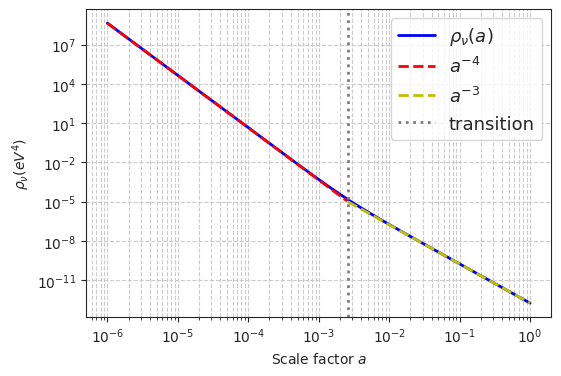

In [5]:
# scale factor array
a = jnp.geomspace(1e-6, 1.0, 500) # a(ini) has to be small enough to ensure convergence of the ODE of D 
x_array = jnp.linspace(jnp.log(a[0]), jnp.log(a[-1]), 500)
a_array = jnp.exp(x_array)

# neutrino density rho_nu(a)
rho_nu = jax.vmap(lambda aa: nu_background(aa, amnu)[0])(a)
# Transfo ev4
rho_nu = rho_nu * g * (Tnu0/conKeV)**4 / 2 / jnp.pi**2 / a**4

# Density of neutrinos today 
rho0 = rho_nu[-1]  
n_nu0 = rho0 / mnu * conv_ev3_to_cm3
n_nu0_th = g * (3 * zeta(3) / (4 * pi**2)) * (Tnu0/conKeV)**3 * conv_ev3_to_cm3
print("Neutrino density today (theoretical formula) : n_nu0_Th(cm-3) =", n_nu0_th)
print("Neutrino density today from computed neutrido density : n_nu0 (cm-3) =", n_nu0)


#  Reference lines 
rho_ref_a4 = rho_nu[0] * (a / a[0])**(-4)  
rho_ref_a3 = rho_nu[-1] * (a / a[-1])**(-3)  

diff = rho_ref_a4 - rho_ref_a3
cross_indices = jnp.where(diff[:-1] * diff[1:] < 0)[0]
idx_cross = cross_indices[0]
a_cross = a[idx_cross]


# Plot 
plt.figure(figsize=(6, 4))
plt.loglog(a, rho_nu,color='blue', label=r'$\rho_\nu(a)$',lw=2)  
plt.loglog(a[:idx_cross], rho_ref_a4[:idx_cross], 'r--', label=r'$a^{-4}$',lw=2)  
plt.loglog(a[idx_cross:], rho_ref_a3[idx_cross:], 'y--', label=r'$a^{-3}$',lw=2)  
plt.axvline(a_cross, color='grey', linestyle=':', label=r'transition',lw=2)  
#plt.axvline(a_nr_val, color="k", ls="--", alpha=0.6, label="a_nr")
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$\rho_\nu (eV^4)$')
#plt.title('Massive neutrino density as a function of scale factor')
plt.grid(True, which='both', ls='--')
plt.legend(loc=1,prop={'size': 13})
plt.show()
#plt.savefig('rhonu.pgf')

In [6]:
def O_nu(a , amnu):
        """Compute the exact massive neutrino density parameter and its derivative"""
        a_arr = jnp.atleast_1d(a)

        def one_a(aa):
            return (
                3 * nu_background(aa, amnu)[0]
                * g * (Tnu0 / conKeV) ** 4
                / (2 * jnp.pi ** 2 * rho_c)
                * aa ** (-4)
            )
        out = jax.vmap(one_a)(a_arr)
        return out[0] if jnp.asarray(a).ndim == 0 else out

def interp(x, xp, yp):
    """Linear interpolation function"""
    idx = jnp.clip(jnp.searchsorted(xp, x) - 1, 0, xp.shape[0] - 2)

    x0 = xp[idx]
    x1 = xp[idx + 1]
    y0 = yp[idx]
    y1 = yp[idx + 1]

    t = (x - x0) / (x1 - x0)
    return y0 + t * (y1 - y0)

Omega_nu_table = None
dOmega_nu_table = None
Omega_nu0_table = None
dOmega_nu0_table = None

def Compute_Omega_nu(m):
    global Omega_nu_table, dOmega_nu_table

    Omega_nu_table = jax.vmap(
        lambda _a: O_nu(_a, m * conKeV / Tnu0)
    )(a)

    dOmega_nu_table = jax.vmap(
        lambda _a: jax.grad(O_nu)(_a, m * conKeV / Tnu0)
    )(a)

def Compute_Omega_nu0(m):
    global Omega_nu0_table, dOmega_nu0_table

    Omega_nu0_table = jax.vmap(
        lambda _a: O_nu(_a, 0 * conKeV / Tnu0)
    )(a)

    dOmega_nu0_table = jax.vmap(
        lambda _a: jax.grad(O_nu)(_a, 0 * conKeV / Tnu0)
    )(a)

Compute_Omega_nu(mnu)
Compute_Omega_nu0(0)

In [7]:
def Omega_nu(x):
    """Compute the interpolated massive neutrino density parameter"""
    return interp(x, a, Omega_nu_table)

def dOmega_nu(x):
    """Compute the derivative of interpolated massive neutrino density parameter"""
    return interp(x, a, dOmega_nu_table)

def Omega_nu0(x):
    """Compute the interpolated massive neutrino density parameter"""
    return interp(x, a, Omega_nu0_table)

def dOmega_nu0(x):
    """Compute the derivative of interpolated massive neutrino density parameter"""
    return interp(x, a, dOmega_nu0_table)

In [8]:
#Vectorize
Omega_nu_array = Omega_nu(a)

In [9]:
def Omega_de(Omega_c , Omega_b ,Omega_k,Omega_gamma_0):
    """Compute the dark energy density parameter with massless neutrinos."""
    return 1.0 - Omega_c - Omega_b - Omega_k - Omega_gamma_0 - Omega_nu0(1)

def Omega_de_wnu(Omega_c , Omega_b ,Omega_k,Omega_gamma_0):
    """Compute the dark energy density parameter with massive neutrinos."""
    return 1.0 - Omega_c - Omega_b - Omega_k - Omega_gamma_0 - Omega_nu(1)

########

def Omega_de_of_a(Omega_de, w0 ,wa, a):
    """Dark energy density term as a function of scale factor."""
    return Omega_de * (a ** (-3 * (1 + w0 + wa)) * jnp.exp(-3 * wa * (1 - a)))
    
########

#Inital Dark energy density parameter with massless/massive neutrinos
Omega_de0 = Omega_de(Omega_c , Omega_b ,Omega_k, Omega_gamma_0) 
Omega_de0_wnu = Omega_de_wnu(Omega_c , Omega_b ,Omega_k, Omega_gamma_0)          
print(Omega_b + Omega_c + Omega_k  + Omega_nu0(1) + Omega_gamma_0 + Omega_de0 )   #RETURN 1
print(Omega_b + Omega_c + Omega_k  + Omega_nu(1)  + Omega_gamma_0 + Omega_de0_wnu)  #RETURN 1

########

def Hubble_const (Omega_c , Omega_b ,Omega_k, a) :
    """Compute the Hubble parameter with massless neutrinos"""
    return H0 *jnp.sqrt( ((Omega_gamma_0) *a**(-4) + (Omega_b + Omega_c) *a**(-3) + Omega_k *a**(-2) + Omega_de_of_a(Omega_de0, w0 ,wa, a)+Omega_nu0(a)) )

def Hubble_const_wnu (Omega_c , Omega_b ,Omega_k, a) :
    """Compute the Hubble parameter with massive neutrinos"""
    return H0 * jnp.sqrt( ((Omega_gamma_0) *a**(-4) + (Omega_b + Omega_c) *a**(-3) + Omega_k *a**(-2) + Omega_de_of_a(Omega_de0_wnu, w0 ,wa, a) + Omega_nu(a)) )


0.9999999999999999
1.0


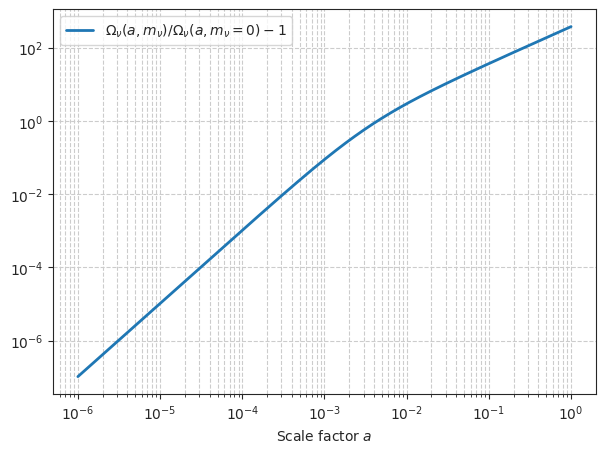

In [10]:
#Test of numerical precision 
plt.figure(figsize=(7.0, 5.0)) 
plt.loglog(a,  (Omega_nu(a)) / (Omega_nu0(a))-1,label=r'$\Omega_{\nu}(a,m_{\nu}) /\Omega_{\nu}(a,m_{\nu}=0) -1$',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.grid(True, which='both', ls='--')
plt.legend(loc="upper left")
plt.show()
#plt.savefig('H_acc.pgf')

In [11]:
#Computation of Hubble constant H with massless/massive neutrinos 
H = Hubble_const(Omega_c , Omega_b ,Omega_k, a)
H_wnu = jnp.array([Hubble_const_wnu(Omega_c, Omega_b, Omega_k, ai) for ai in a])

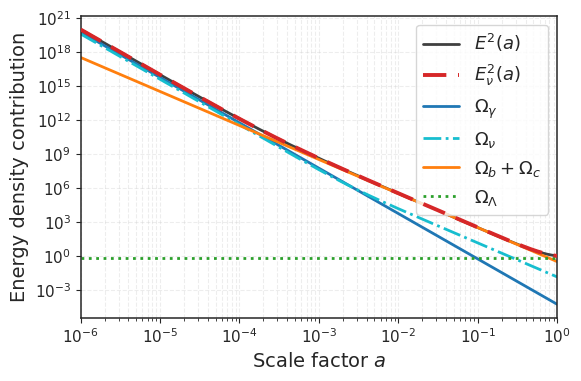

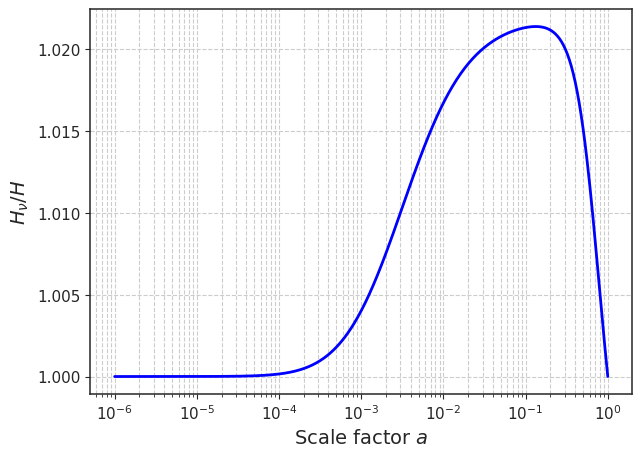

Hubble constant today : H0(a=1) 67.0


In [12]:
#Plot H vs H_wnu

# Style global
mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.1,
})

fig, ax = plt.subplots(figsize=(6, 4))
# Courbe principale
ax.loglog(
    a, (H/H0)**2,
    color='black',
    lw=2.0,
    alpha=0.75,
    label=r'$E^2(a)$',
    zorder=2
)
# Courbe avec neutrinos mise en avant
ax.loglog(
    a, (H_wnu/H0)**2,
    color='#d62728',
    lw=2.8,
    ls=(0, (6, 3)),
    label=r'$E_\nu^2(a)$',
    zorder=10
)
# --- Components ---
ax.loglog(
    a, Omega_gamma_0 * a**-4,
    color='#1f77b4',
    lw=2,
    ls='-',
    label=r'$\Omega_\gamma$'
)
ax.loglog(
    a, Omega_nu_array,
    color='#17becf',
    lw=2,
    ls='-.',
    label=r'$\Omega_\nu$'
)
ax.loglog(
    a, (Omega_b + Omega_c) * a**-3,
    color='#ff7f0e',
    lw=2,
    ls='-',
    label=r'$\Omega_b+\Omega_c$'
)
ax.loglog(
    a,
    Omega_de_of_a(Omega_de0_wnu, w0, wa, a),
    color='#2ca02c',
    lw=2,
    ls=':',
    label=r'$\Omega_\Lambda$'
)
# Labels
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'Energy density contribution')

# Grid
ax.grid(
    True,
    which='both',
    ls='--',
    alpha=0.35
)

# Legend
ax.legend(
prop={'size': 13}
)

# Margins
ax.set_xlim(a.min(), a.max())

plt.tight_layout()

# Save BEFORE show
#plt.savefig("H.pgf", bbox_inches='tight')

plt.show()


#Plot relative deviation [(H_wnu/H)-1]
plt.figure(figsize=(7, 5))
plt.semilogx(a, abs(H_wnu/H),color='blue',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H_{\nu}/H$')
plt.grid(True, which='both', ls='--')
plt.show()
#plt.savefig('Hdiff.pgf')

#Print conpute Hubble const today (to be compared with theoretical value fixed in cosmology)
print('Hubble constant today : H0(a=1)',H[-1])

In [13]:
def E(a) :
    """Dimensionless Hubble parameter as a function of scale factor."""
    return jnp.sqrt((Omega_gamma_0) * a ** -4 + Omega_m0 * a ** -3 + Omega_k * a ** -2 + Omega_de_of_a(Omega_de0, w0 ,wa, a) + Omega_nu0(a))

def E_nu(a) :
    """Dimensionless Hubble parameter as a function of scale factor."""
    return jnp.sqrt((Omega_gamma_0) * a ** -4 + Omega_m0 * a ** -3 + Omega_k * a ** -2 + Omega_de_of_a(Omega_de0_wnu, w0 ,wa, a) + Omega_nu(a))

    
def Eda(a) :
    """Compute the derivative of the dimensionless Hubble parameter E(a) with respect to a.
    """
    #Radiation term
    radiation_term = (Omega_gamma_0) * a ** -4
    dradiation_term = -4 * (Omega_gamma_0) * a ** -5
    # Matter term
    matter_term = Omega_m0 * a ** -3
    dmatter_da = -3 * Omega_m0 * a ** -4
    # Curvature term
    curvature_term = Omega_k * a ** -2
    dcurvature_da = -2 * Omega_k * a ** -3
    # Dark energy term
    de_term =  Omega_de_of_a(Omega_de0, w0 ,wa, a)
    dde_da = Omega_de0 * (3 * a ** (-4 - 3 *w0 - 3 * wa)* jnp.exp(-3 *wa * (1 - a)) * (-1 - w0 + (a - 1) * wa))
    
    # Neutrino term
    nu_term = Omega_nu0(a)
    dnu_term = dOmega_nu0(a)

    dE2_da = dradiation_term + dmatter_da + dcurvature_da + dde_da + dnu_term
    E = jnp.sqrt(radiation_term + matter_term + curvature_term + de_term + nu_term)
    return 0.5 * dE2_da / E


def Eda_nu(a) :
    """Compute the derivative of the dimensionless Hubble parameter E(a) with respect to a.
    """
    #Radiation term
    radiation_term = (Omega_gamma_0) * a ** -4
    dradiation_term = -4 * (Omega_gamma_0) * a ** -5
    # Matter term
    matter_term = Omega_m0 * a ** -3
    dmatter_da = -3 * Omega_m0 * a ** -4
    # Curvature term
    curvature_term = Omega_k * a ** -2
    dcurvature_da = -2 * Omega_k * a ** -3
    # Dark energy term
    de_term =  Omega_de_of_a(Omega_de0_wnu, w0 ,wa, a)
    dde_da = Omega_de0_wnu * (3 * a ** (-4 - 3 * w0 - 3 * wa)* jnp.exp(-3 * wa * (1 - a)) * (-1 - w0 + (a - 1) * wa))
    
    # Neutrino term
    nu_term = Omega_nu(a)
    dnu_term = dOmega_nu(a)

    dE2_da = dradiation_term + dmatter_da + dcurvature_da + dde_da + dnu_term
    E = jnp.sqrt(radiation_term + matter_term + curvature_term + de_term + nu_term)
    return 0.5 * dE2_da / E

def Om_a(a,E):
    return ((Omega_m0)* a**-3) / E**2

In [14]:
g_gamma_nu_0 = (Omega_gamma_0 +Omega_gamma_0 * 3.046 * (7/8) * (4/11)**(4/3)) / (Omega_b + Omega_c)

In [15]:
def rk4_integrate(func, y0, t_array):
    """Integrates using RK4 method with jax.lax.scan for variable time steps.
    
    :param func: Function representing the ODE (dy/dt = func(t, y)).
    :param y0: Initial value of y.
    :param t_array: Array of time steps where integration is evaluated.
    :return: Array of y values corresponding to t_array.
    """

    def rk4_step(carry, t_next):
        """Performs a single RK4 step."""
        y, t = carry
        dt = t_next - t
        k1 = func(t, y)
        k2 = func(t + dt / 2, y + dt / 2 * k1)
        k3 = func(t + dt / 2, y + dt / 2 * k2)
        k4 = func(t + dt, y + dt * k3)
        y_out = y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        return (y_out, t_next), y_out

    # Perform scan
    _, y_values = jax.lax.scan(rk4_step, (y0, t_array[0]), t_array[1:])
    return jnp.concatenate([y0[None, :], y_values])

In [16]:
def compute_unnormed_growth(a, a_min_integration):
        """Solve the ODE for the unnormalized growth factor as a function of scale factor."""
        # If double precision is enabled, solve the ODE with 64-bit precision and convert to 32-bit
        if jax.config.read("jax_enable_x64") and a.dtype == jnp.float32:
            a = a.astype(jnp.float64)
            eps = jnp.finfo(jnp.float64).eps
        else:
            eps = jnp.finfo(jnp.float32).eps

        ln_a = jnp.log(a)

        D0 = a_min_integration + (2/3) * g_gamma_nu_0
        y1_0 = jnp.log(D0)
        f1_0 = a_min_integration / D0
        y0_log = jnp.array([y1_0, f1_0])

        def growth_derivs_log_signed(ln_a, y):
            """
            State: [y1,f1]
            """
            a_loc = jnp.exp(ln_a)
            a_loc = jnp.maximum(a_loc, eps)
            E_val = E(a_loc)
            dE = Eda(a_loc)
            Om_a = ((Omega_m0  ) * a_loc ** -3) / E_val**2
       
            # Unpack
            (y1, f1) = y

            # Drag coefficient
            drag = 2 + (a_loc / E_val) * dE

            # D1
            dy1 = f1
            df1 = 1.5 * Om_a - f1 ** 2 - f1 * drag
            D1 = jnp.exp(y1)
            D1_sq = D1 ** 2
            D1_cu = D1 ** 3
            return jnp.array([dy1, df1])

        ys_log = rk4_integrate(jax.jit(growth_derivs_log_signed), y0_log, ln_a)
        (y1, f1) = ys_log.T
        D1 = jnp.exp(y1)
        D1p = f1 * D1 / a
        return [D1, D1p]

def compute_unnormed_growth_nu(a, a_min_integration):
        """Solve the ODE for the unnormalized growth factor as a function of scale factor."""
        # If double precision is enabled, solve the ODE with 64-bit precision and convert to 32-bit
        if jax.config.read("jax_enable_x64") and a.dtype == jnp.float32:
            a = a.astype(jnp.float64)
            eps = jnp.finfo(jnp.float64).eps
        else:
            eps = jnp.finfo(jnp.float32).eps

        ln_a = jnp.log(a)

        D0 = a_min_integration + (2/3) * g_gamma_nu_0
        y1_0 = jnp.log(D0)
        f1_0 = a_min_integration / D0
        y0_log = jnp.array([y1_0, f1_0])

        def growth_derivs_log_signed_nu(ln_a, y):
            """
            State: [y1,f1]
            """
            a_loc = jnp.exp(ln_a)
            a_loc = jnp.maximum(a_loc, eps)
            E_val = E_nu(a_loc)
            dE = Eda_nu(a_loc)
            Om_a = ((Omega_m0  ) * a_loc ** -3) / E_val**2
       
            # Unpack
            (y1, f1) = y

            # Drag coefficient
            drag = 2 + (a_loc / E_val) * dE

            # D1
            dy1 = f1
            df1 = 1.5 * Om_a - f1 ** 2 - f1 * drag
            D1 = jnp.exp(y1)
            D1_sq = D1 ** 2
            D1_cu = D1 ** 3
            return jnp.array([dy1, df1])

        ys_log = rk4_integrate(jax.jit(growth_derivs_log_signed_nu), y0_log, ln_a)
        (y1, f1) = ys_log.T
        D1 = jnp.exp(y1)
        D1p = f1 * D1 / a
        return [D1, D1p]

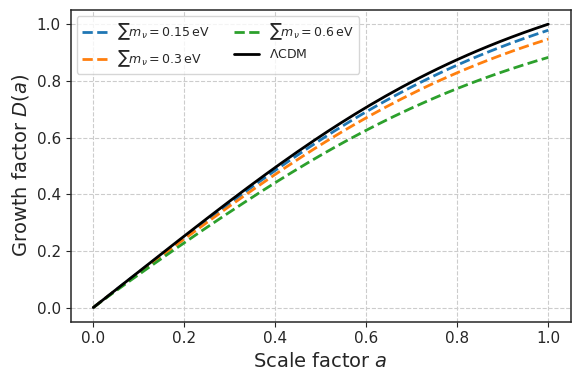

<Figure size 640x480 with 0 Axes>

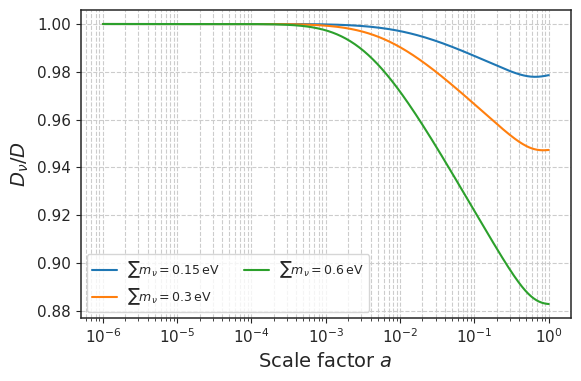

<Figure size 640x480 with 0 Axes>

In [ ]:
a_ini = a[0]
D = jnp.array(compute_unnormed_growth(a, a_ini)[0])
Norm_fact= D[-1]
D = D/Norm_fact
results = []

for m in [0.15/3, 0.3/3, 0.6/3]:
    Compute_Omega_nu(m)


    D_nu = jnp.array(compute_unnormed_growth_nu(a, a_ini)[0])

    D_nu = D_nu / Norm_fact

    results.append({"D": D_nu, "mass": 3*m})

np.save("growth.npy", results, allow_pickle=True)

all_data = np.load("growth.npy", allow_pickle=True)
all_data = list(all_data)

plt.figure(figsize=(6,4))

masses = sorted(set(d["mass"] for d in all_data))

for d in all_data:
    D1 = d["D"]
    mass = d["mass"]


    plt.plot(
        a,
        D1,
        '--', lw=2,
             label=fr"$\sum m_\nu = {mass}\,\mathrm{{eV}}$"
    )
plt.plot(a, D, color='black', lw=2, label=r'$\Lambda$CDM')
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('D.pgf')

plt.figure(figsize=(6,4))

for d in all_data:
    D1 = d["D"]
    mass = d["mass"]


    plt.semilogx(
        a,
        D1/D,
        label=fr"$\sum m_\nu = {mass}\,\mathrm{{eV}}$"
    )
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D_\nu/D$')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('D_diff.pgf')